### **Imports Iniciales**

In [38]:
import re, time, unicodedata, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display

# NLP clásico
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize, sent_tokenize

# Representación y modelos (solo scikit-learn, sin redes neuronales)
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

# Evaluación
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

warnings.filterwarnings(action='ignore')
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
plt.style.use(style='seaborn-v0_8-whitegrid')

SEMILLA = 42
CLASES = ['negativo', 'neutral', 'positivo']
print('✓ Entorno listo')

✓ Entorno listo


### **1. Carga de datos**

In [39]:
train_raw = pd.read_csv('data/train.csv')
eval_raw = pd.read_csv('data/eval.csv')

display(train_raw.head())

,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


### **2. Calidad de datos**

Para la verificación de la calidad de datos, se parte por la siguiente hipótesis: Que la columna *id* sea única no garantiza que los datos no lo sean, por lo que se va a verificar la **dimensiones de calidad** de las filas en dos niveles:

1. **Estructural:** *id* único, nulos, textos vacíos, etiquetas válidas. Esto quiere decir que en este nivel, se verificará la **unicidad**, **completitud** y **consistencia** en su forma "clásica".
2. **De contenido:** Textos repetidos (exactos y casi exactos) y, sobre todo, textos con **etiquetas distintas** (ruido de etiqueta). Es decir, se verificará la **unicidad** y **consistencia** de los datos.

Se hace esta verificación porque si una reseña duplicada cae en el fold de entrenamiento y en el de validación a la vez, la exactitud de validación se infla (data leakage) y elegiríamos hiperparámetros con una métrica optimista (sobreestima los datos).

In [40]:
def auditar(df, nombre, con_label=True):
    print(f'-- {nombre} --')
    print(f'Filas: {len(df):,}')
    print(f'Nulos por columna: {df.isna().sum().to_dict()}')
    print(f'IDs únicos: {df["id"].is_unique} (IDs repetidos: {df["id"].duplicated().sum()})')
    print(f'Textos vacíos o solo espacios: {df["text"].fillna("").str.strip().eq("").sum()}')
    if con_label:
        etiquetas = df["label"].astype(str).str.strip().str.lower()
        fuera = sorted(set(etiquetas) - set(CLASES))
        print(f'Etiquetas fuera de {CLASES}: {fuera if fuera else "ninguna"}')
        print(f'Etiquetas con espacios/Mayúsculas por corregir: {(etiquetas != df["label"]).sum()}')
    print()

auditar(train_raw, 'train')
auditar(eval_raw, 'eval', con_label = False)

-- train --
Filas: 12,000
Nulos por columna: {'id': 0, 'text': 0, 'label': 0}
IDs únicos: True (IDs repetidos: 0)
Textos vacíos o solo espacios: 0
Etiquetas fuera de ['negativo', 'neutral', 'positivo']: ninguna
Etiquetas con espacios/Mayúsculas por corregir: 0

-- eval --
Filas: 3,000
Nulos por columna: {'id': 0, 'text': 0}
IDs únicos: True (IDs repetidos: 0)
Textos vacíos o solo espacios: 0



In [41]:
#Se crea una columna auxiliar 'clave' "laxa" para comparar el parecido con 'text'

def clave_duplicado(s):
    #Estandariza espacios
    return s.fillna('').str.lower().str.replace(r'\s+', ' ', regex=True)

#Se hace una copia del dataset de entrenamiento como buena práctica
train = train_raw.copy()
train['label'] = train['label'].astype(str).str.strip().str.lower()
train['clave'] = clave_duplicado(train['text'])

grupos = train.groupby('clave')['label'].agg(['size', 'nunique'])
dup_mismo_label = grupos[(grupos['size'] > 1) & (grupos['nunique'] == 1)]
dup_conflicto = grupos[grupos['nunique'] > 1]

print(f'Duplicados exactos (texto crudo): {train["text"].duplicated().sum()}')
print(f'Duplicados por clave laxa: {train["clave"].duplicated().sum()}')
print(f'grupos con la misma etiqueta: {len(dup_mismo_label)} (filas sobrantes: {(dup_mismo_label["size"] - 1).sum()})')
print(f'Grupos con etiquetas en conflicto: {len(dup_conflicto)} (filas involucradas: {dup_conflicto["size"].sum()})')

if len(dup_conflicto):
    display(train[train['clave'].isin(dup_conflicto.index)].sort_values('clave')[['id', 'text', 'label']].head(10))

#Unicamente se verifica si hay datos solapados entre datos de train y eval
solapamiento = set(train['clave']) & set(clave_duplicado(eval_raw['text']))
print(f'Textos de eval que también aparecen en train: {len(solapamiento)}')

Duplicados exactos (texto crudo): 0
Duplicados por clave laxa: 0
grupos con la misma etiqueta: 0 (filas sobrantes: 0)
Grupos con etiquetas en conflicto: 0 (filas involucradas: 0)
Textos de eval que también aparecen en train: 0


In [42]:
n_inicial = len(train)
train = train[train['clave'] != '']
train = train[~train['clave'].isin(dup_conflicto.index)]
train = train.drop_duplicates(subset='clave', keep = 'first')
train = train.drop(columns='clave').reset_index(drop=True)

eval_df = eval_raw.copy()
eval_df['text'] = eval_df['text'].fillna('')

print(f'train: {n_inicial:,}: {len(train):,} filas (eliminadas: {n_inicial - len(train):,})')

train: 12,000: 12,000 filas (eliminadas: 0)


**Resultado:** el conjunto de datos no presenta problemas en ninguna de las dimensiones evaluadas:

- **Completitud:** no hay nulos ni textos vacíos en `train` ni en `eval`.
- **Unicidad:** no hay IDs repetidos ni reseñas duplicadas (ni exactas ni con la clave laxa).
- **Consistencia:** todas las etiquetas pertenecen a las tres clases válidas y no existen textos iguales con etiquetas distintas.
- **Fuga de información:** ninguna reseña de `eval` aparece en `train`.

La limpieza de la celda anterior no elimina filas, pero se conserva para que el flujo sea robusto si los datos cambian.

### **3. Exploración rápida**

- Balanceo de clases
- Longitud de las reseñas
- Diferencia de palabras de negación y contraste por clase (para no tratarlas como *stopwords*)
- Estructura de las reseñas: oraciones y conectores contrastivos

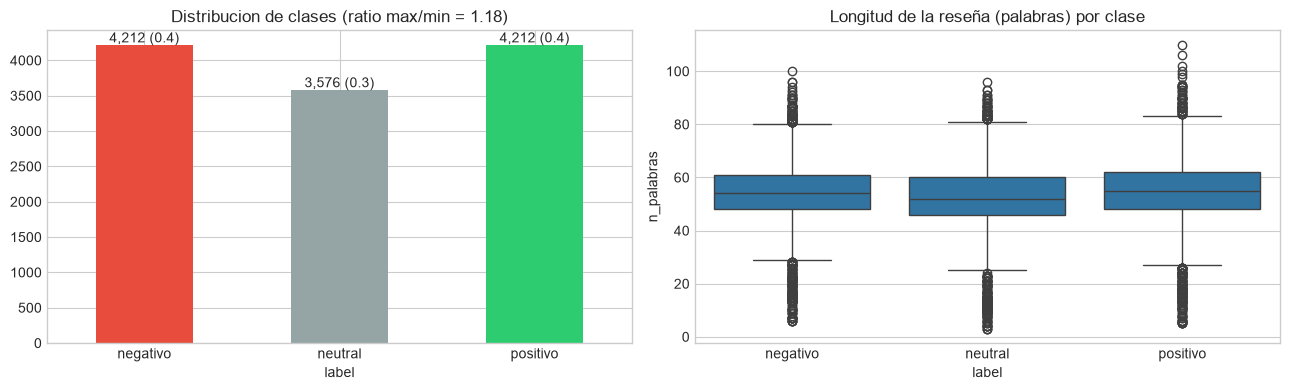

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negativo,4212.0,54.2,12.7,6.0,48.0,54.0,61.0,100.0
neutral,3576.0,52.3,13.9,3.0,46.0,52.0,60.0,96.0
positivo,4212.0,55.0,13.0,5.0,48.0,55.0,62.0,110.0


In [43]:
conteo = train['label'].value_counts().reindex(CLASES)
ratio_desbalance = conteo.max() / conteo.min()
train['n_palabras'] = train['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
conteo.plot.bar(ax = axes[0], color = ['#E74C3C', '#95A5A6', '#2ECC71'], rot = 0)
axes[0].set_title(f'Distribucion de clases (ratio max/min = {ratio_desbalance:.2f})')
for i, v in enumerate(conteo):
    axes[0].text(i, v, f'{v:,} ({v / conteo.sum():.1f})', ha='center', va='bottom')
sns.boxplot(data=train, x='label', y='n_palabras', order=CLASES, ax=axes[1])
axes[1].set_title('Longitud de la reseña (palabras) por clase')
plt.tight_layout()
plt.show()

display(train.groupby('label')['n_palabras'].describe().reindex(CLASES).round(1))

In [44]:
# % de reseñas de cada clase que contienen el marcador
marcadores = ['no', 'nunca', 'nada', 'sin', 'pero', 'aunque', 'sin embargo', 'muy']
tabla = pd.DataFrame({
    m: train.groupby('label')['text'].apply(lambda s: s.str.lower().str.contains(rf'\b{m}\b', regex = True).mean() * 100) for m in marcadores
}).reindex(CLASES)
display(tabla.round(1))

PATRON_ESPECIALES = r'[^a-zA-ZáéíóúüñÁÉÍÓÚÜÑ0-9\s.,;:!?¡¿()\'"\-]'
otros = train['text'].str.findall(PATRON_ESPECIALES).explode().dropna()
pct_especiales = train['text'].str.contains(PATRON_ESPECIALES, regex=True).mean()
print(f'Reseñas con caracteres especiales: {pct_especiales:.1%}')
print('Más frecuentes: ', otros.value_counts().head(15).to_dict())

,no,nunca,nada,sin,pero,aunque,sin embargo,muy
label,,,,,,,,
negativo,27.1,0.2,18.3,23.4,9.5,4.9,1.5,10.8
neutral,40.6,0.1,27.3,27.7,3.7,2.7,0.0,0.2
positivo,25.9,0.2,16.5,23.4,3.8,3.9,1.4,8.2


Reseñas con caracteres especiales: 0.1%
Más frecuentes:  {'Ã': 24, '\xad': 16, '³': 4, '±': 3, '©': 3, 'ì': 3, 'è': 2, 'à': 2, 'º': 1, '%': 1, 'ò': 1}


Solo el 0.1% de las reseñas (4 en train, ninguna en eval) tiene caracteres extraños como "Ã" o "\xad" . No son emojis ni ruido intencional: es **mojibake**, texto UTF-8 que fue leído como Latin-1 (por ejemplo aquÃ\xad → aquí, reseÃ±a → reseña). En lugar de eliminarlos, se reparan en el preprocesamiento con la función reparar_codificacion (sección 4).

In [45]:
train['n_oraciones'] = train['text'].apply(lambda s: len(sent_tokenize(s, language = 'spanish')))
display(train.groupby('label')['n_oraciones'].describe().reindex(CLASES).round(2))
print(f'Reseñas con más de una oración: {(train["n_oraciones"] > 1).mean():.1%}')

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negativo,4212.0,3.85,0.79,1.0,3.0,4.0,4.0,7.0
neutral,3576.0,3.89,0.73,1.0,4.0,4.0,4.0,6.0
positivo,4212.0,3.93,0.78,1.0,4.0,4.0,4.0,7.0


Reseñas con más de una oración: 98.9%


In [46]:
# Conectores contrastivos más frecuentes en el corpus (se unen en un solo token en la sección 4)
CONTRASTE_RE = re.compile(
    r'\b(pero|aunque|sin embargo|no obstante|aun as[ií]|eso s[ií]|por otro lado|con todo|al final|de todos modos|de todas formas|por cierto|de paso|ahora bien|en cambio|sino|mientras que)\b',
    flags=re.IGNORECASE)

conectores = train['text'].str.findall(CONTRASTE_RE).explode().dropna().str.lower().map(lambda c: unicodedata.normalize('NFKD', c).encode('ascii', 'ignore').decode())
display(conectores.value_counts().to_frame('apariciones').T)

train['n_conectores'] = train['text'].str.count(CONTRASTE_RE)
tabla_conectores = pd.crosstab(train['label'], train['n_conectores'].clip(upper=2), normalize='index').mul(100).round(1)
tabla_conectores.columns = ['0 conectores', '1 conector', '2 o más']
display(tabla_conectores.reindex(CLASES))

text,eso si,al final,aun asi,por otro lado,pero,por cierto,de paso,aunque,con todo,sin embargo,en cambio,de todos modos,ahora bien,de todas formas,sino
apariciones,1734,1234,752,737,695,683,631,468,435,122,32,17,15,11,2


,0 conectores,1 conector,2 o más
label,,,
negativo,35.2,49.3,15.5
neutral,76.5,21.2,2.2
positivo,39.3,48.2,12.5


In [47]:
# Una reseña completa por clase para ver su estructura
with pd.option_context('display.max_colwidth', None):
    display(train.groupby('label').sample(1, random_state=7)[['label', 'text']].reindex(columns=['label', 'text']))

,label,text
7190,negativo,"Lo compré hace un par de meses para usar en casa, nada del otro mundo en cuanto a envío, llegó en unos cuatro días. El soporte técnico vale totalmente la pena, la verdad me atendieron cuando llamé por una duda de instalación. Por otro lado, le pondría una estrella al menú de ajustes. Total, que tengo sentimientos encontrados con esto."
3991,neutral,"Lo compré hace unos días en línea y me llegó al tercer día. Viene en color gris, tal como se ve en las fotos. Lo llevo a todas partes, lo tengo en la mochila para el trabajo. Pesa poco y no ocupa espacio."
2660,positivo,"Bueno, me animo a comentar porque lo compré hace un mes y medio en una oferta de esas de medianoche. El rendimiento es justo lo que estaba buscando, la verdad. Ahora, el procesador me dio más de un dolor de cabeza, sobre todo la primera semana que lo estuve configurando en la oficina. Todavía no me decido."


**Conclusiones de la exploración**

1. **Clases casi balanceadas** (ratio max/min ≈ 1.18). No se necesita remuestreo y la exactitud (*accuracy*), que es la métrica de la competencia, es representativa. Se descarta SMOTE: además de innecesario, interpolar vectores TF-IDF dispersos genera "documentos" artificiales sin sentido lingüístico.
2. **La longitud no discrimina:** las tres clases tienen distribuciones casi idénticas de palabras (~54) y oraciones (~4).
3. **La negación no es sinónimo de negatividad:** *no*, *nada* y *sin* son **más** frecuentes en las reseñas neutrales que en las negativas (p. ej. "sin nada fuera de lo común"). Por eso no se eliminan como *stopwords*, pero tampoco se tratan como señal negativa directa: se marca su alcance.
4. **Intensificadores y conectores sí son informativos:** *muy* casi no aparece en neutrales (0.2%) y *pero* es 2.5 veces más frecuente en negativas.
5. **Estructura de las reseñas:** las primeras oraciones suelen ser logística (cuándo se compró, cuánto tardó el envío, dónde se usa) y no aportan sentimiento. El 87% de las reseñas neutrales no tiene ningún conector contrastivo, frente a solo el 42-47% de las positivas y negativas. Más de la mitad de las reseñas con sentimiento tiene al menos un conector, señal de que mezcla un elogio y una queja, y en muchas de ellas el sentimiento global coincide con **la última opinión expresada** (recencia), tal como advierte el enunciado. No es una regla absoluta: la reseña positiva de ejemplo termina con una queja. Esta observación motiva la segmentación posicional de la sección 5.

### **4. Preprocesamiento adaptado a análisis de sentimiento**

In [48]:
def sin_tildes(s):
    s = s.replace('ñ', '§')
    s = ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c))
    return s.replace('§', 'ñ')

def reparar_codificacion(s):
    # Corrige texto UTF-8 leído como Latin-1 (mojibake), p. ej. 'aquÃ\xad' -> 'aquí'
    if re.search(r'[ÃÂ]', s):
        try:
            s = s.encode('latin1').decode('utf8')
        except UnicodeError:
            pass
    return s.replace('\xad', '')

# Conectores de varias palabras que se unen en un solo token (las claves son regex: 'aun así' / 'aun asi')
CONECTORES_MULTI = {'sin embargo': 'sin_embargo', 'no obstante': 'no_obstante', 'a pesar de': 'a_pesar_de',
                    'aun as[ií]': 'aun_asi', 'eso s[ií]': 'eso_si', 'por otro lado': 'por_otro_lado',
                    'con todo': 'con_todo', 'al final': 'al_final',
                    'de todos modos': 'de_todos_modos', 'de todas formas': 'de_todas_formas',
                    'por cierto': 'por_cierto', 'de paso': 'de_paso', 'ahora bien': 'ahora_bien',
                    'en cambio': 'en_cambio', 'mientras que': 'mientras_que'}
NEGADORES  = {'no', 'ni', 'nunca', 'jamas', 'tampoco', 'sin', 'nada', 'nadie', 'ningun', 'ninguno', 'ninguna'}
# 'igual' no se incluye: en el corpus suele ser comparativo ("el color es igual al de las fotos")
ADVERSATIVOS = {'pero', 'sino', 'sin_embargo', 'no_obstante', 'aun_asi', 'eso_si', 'por_otro_lado',
                'con_todo', 'al_final', 'de_todos_modos', 'de_todas_formas',
                'por_cierto', 'de_paso', 'ahora_bien', 'en_cambio', 'mientras_que'}
CONCESIVOS   = {'aunque', 'a_pesar_de'}
INTENSIDAD = {'muy', 'mas', 'menos', 'mucho', 'mucha', 'muchos', 'muchas', 'poco', 'poca', 'pocos', 'pocas',
              'tan', 'tanto', 'demasiado', 'bastante', 'algo', 'todo'}

PALABRAS_A_CONSERVAR = NEGADORES | ADVERSATIVOS | CONCESIVOS | INTENSIDAD
stop_nltk = {sin_tildes(w) for w in stopwords.words('spanish')}
STOPWORDS_SENTIMIENTO = stop_nltk - PALABRAS_A_CONSERVAR

print(f'Stopwords NLTK: {len(stop_nltk)}: personalizadas: {len(STOPWORDS_SENTIMIENTO)}')
print('Rescatadas de la lista de NLTK:', sorted(stop_nltk & PALABRAS_A_CONSERVAR))

Stopwords NLTK: 306: personalizadas: 293
Rescatadas de la lista de NLTK: ['algo', 'mas', 'mucho', 'muchos', 'muy', 'nada', 'ni', 'no', 'pero', 'poco', 'sin', 'tanto', 'todo']


In [49]:
PALABRA_RE = re.compile(r'[a-záéíóúüñ_]+|\d+(?:[.,]\d+)?')
PUNTUACION = set('.,;:!?¡¿()') | {'...'}
stemmer = SnowballStemmer('spanish')
SUPERLATIVO_RE = re.compile(r'\b([a-záéíóúñ]{3,}?)[ií]sim[oa]s?\b')

def _superlativo(m):
    raiz = m.group(1)
    if raiz.endswith('qu'):
        raiz = raiz[:-2] + 'c'
    elif raiz.endswith('gu'):
        raiz = raiz[:-1]
    elif raiz.endswith('bil'):
        return f'muy {raiz[:-3]}ble'
    return f'muy {raiz}o'

def preprocesar(texto, stemming=True, quitar_tildes=True, negacion=True, ventana_neg=3,
                contraste=False, concesion=False, ventana_conc=8, numeros='mantener'):

    if not isinstance(texto, str):
        return ''

    t = reparar_codificacion(texto).lower()
    t = re.sub(r'https?://\S+|www\.\S+', ' ', t)
    t = re.sub(r'([aeiouáéíóú])\1{2,}', r'\1', t)
    t = re.sub(r'(.)\1{2,}', r'\1\1', t)
    t = SUPERLATIVO_RE.sub(_superlativo, t)
    for frase, unido in CONECTORES_MULTI.items():
        t = re.sub(r'\b' + frase.replace(' ', r'\s+') + r'\b', unido, t)
    t = re.sub(r'\bahora(?=\s*,)', 'ahora_bien', t)
    if numeros == 'eliminar':
        t = re.sub(r'\d+(?:[.,]\d+)?', ' ', t)
    elif numeros == 'token':
        t = re.sub(r'\d+(?:[.,]\d+)?', ' num ', t)
    t = re.sub(r'([¡¿])', r' \1 ', t)

    salida, neg_restante, conc_restante, idx_contraste = [], 0, 0, -1
    for tok in word_tokenize(t, language='spanish'):
        if tok in PUNTUACION:
            neg_restante = 0
            conc_restante = 0
            continue
        tok = tok.rstrip('.')
        if not PALABRA_RE.fullmatch(tok):
            continue
        base = sin_tildes(tok)
        if base in STOPWORDS_SENTIMIENTO:
            continue
        if base in PALABRAS_A_CONSERVAR:
            forma = base
        elif base[0].isdigit():
            forma = re.sub(r'[.,]', '_', base)
        else:
            forma = stemmer.stem(tok) if stemming else tok
            if quitar_tildes:
                forma = sin_tildes(forma)
            if negacion and neg_restante > 0:
                forma = 'neg' + forma
                neg_restante -= 1
            if concesion and conc_restante > 0:
                forma = 'conc_' + forma
                conc_restante -= 1

        if base in ADVERSATIVOS or base in CONCESIVOS:
            neg_restante = 0
            conc_restante = 0
        if concesion and base in CONCESIVOS:
            conc_restante = ventana_conc
        if negacion and base in NEGADORES:
            neg_restante = ventana_neg

        salida.append(forma)
        if base in ADVERSATIVOS:
            idx_contraste = len(salida)

    if contraste and idx_contraste >= 0:
        salida = salida[:idx_contraste] + ['tras_' + w for w in salida[idx_contraste:]]
    return ' '.join(salida)

Se verifica el comportamiento de preprocesar en un ejemplo con negación y contraste, y la reparación de codificación en una reseña real con mojibake:

In [50]:
ejemplo = 'La batería es excelente, pero la cámara no funciona bien. Aun así, la volvería a comprar.'
print(ejemplo)
for nombre, kwargs in {'base': dict(negacion=False), 'negación': dict(negacion=True),
                       'negación + contraste': dict(negacion=True, contraste=True)}.items():
    print(f'  {nombre:22s}→ {preprocesar(ejemplo, **kwargs)}')

con_mojibake = train.loc[train['text'].str.contains('Ã'), 'text'].iloc[0]
print('\nOriginal :', con_mojibake[:80])
print('Reparado :', reparar_codificacion(con_mojibake)[:80])

La batería es excelente, pero la cámara no funciona bien. Aun así, la volvería a comprar.
  base                  → bat excelent pero cam no funcion bien aun_asi volv compr
  negación              → bat excelent pero cam no negfuncion negbien aun_asi volv compr
  negación + contraste  → bat excelent pero cam no negfuncion negbien aun_asi tras_volv tras_compr

Original : Pues aquÃ­ va lo prometido, mi reseÃ±a del artÃ­culo. Me llegÃ³ el martes por la
Reparado : Pues aquí va lo prometido, mi reseña del artículo. Me llegó el martes por la tar


Verificación del tokenizador: se compara split() con word_tokenize para confirmar que punkt separa correctamente la puntuación. Esto es necesario porque preprocesar corta el alcance de la negación en comas y puntos.

In [51]:
for s in ['No lo recomiendo, etc. Nunca más!!!', '¿Vale la pena? No, cuesta 4.5 millones.']:
    print(s)
    print('  split()       →', s.lower().split())
    print('  word_tokenize →', word_tokenize(re.sub(r'([¡¿])', r' \1 ', s.lower()), language='spanish'))
    print()

No lo recomiendo, etc. Nunca más!!!
  split()       → ['no', 'lo', 'recomiendo,', 'etc.', 'nunca', 'más!!!']
  word_tokenize → ['no', 'lo', 'recomiendo', ',', 'etc.', 'nunca', 'más', '!', '!', '!']

¿Vale la pena? No, cuesta 4.5 millones.
  split()       → ['¿vale', 'la', 'pena?', 'no,', 'cuesta', '4.5', 'millones.']
  word_tokenize → ['¿', 'vale', 'la', 'pena', '?', 'no', ',', 'cuesta', '4.5', 'millones', '.']



#### Línea base: función de limpieza vista en clase

Se conserva la función de limpieza genérica vista en clase como **línea base de comparación**. Para este problema tiene tres limitaciones:
1. Usa PorterStemmer, diseñado para inglés (en español deja raíces incorrectas).
2. Elimina con las *stopwords* de NLTK palabras clave para el sentimiento como *no*, *pero* y *muy*.
3. No hace nada respecto al orden de las cláusulas.

En la sección 7 se mide cuánto pierde frente a preprocesar.

In [52]:
_porter, _stop_es = nltk.PorterStemmer(), set(stopwords.words('spanish'))
def limpiar_texto_clase(texto):
    #Normalizacion
    texto = re.sub(r'[^\w\s]', '', texto.lower())
    texto = re.sub(r'\d+', '', texto)  # eliminar números
    tokens = [t for t in texto.split() if t not in _stop_es and len(t) > 2]
    return ' '.join(_porter.stem(t) for t in tokens)

In [53]:
#Se generan las variantes como columnas para comparar al vectorizar/modelar
VARIANTES = {
    'texto_base':               dict(negacion=False),
    'texto_neg':                dict(negacion=True),
    'texto_neg_contraste':      dict(negacion=True, contraste=True),
    'texto_neg_contraste_conc': dict(negacion=True, contraste=True, concesion=True),
}

for col, kwargs in VARIANTES.items():
    train[col] = train['text'].apply(preprocesar, **kwargs)
    eval_df[col] = eval_df['text'].apply(preprocesar, **kwargs)
train['texto_clase'] = train['text'].apply(limpiar_texto_clase)
eval_df['texto_clase'] = eval_df['text'].apply(limpiar_texto_clase)

def tam_vocabulario(serie):
    return len(set(' '.join(serie).split()))

vocab_crudo = tam_vocabulario(train['text'].str.lower().str.replace(r'[^\w\s]', ' ', regex=True))
print(f'Vocabulario crudo: {vocab_crudo:,}')
for col in ['texto_clase', *VARIANTES]:
    v = tam_vocabulario(train[col])
    print(f'{col:26s}: {v:,} ({v / vocab_crudo - 1:+.1%} respecto al crudo)')

vacios = (train['texto_neg'].str.strip() == '').sum()
print(f'\nReseñas que quedaron vacías tras la limpieza: {vacios}')

Vocabulario crudo: 6,054
texto_clase               : 5,246 (-13.3% respecto al crudo)
texto_base                : 3,075 (-49.2% respecto al crudo)
texto_neg                 : 3,905 (-35.5% respecto al crudo)
texto_neg_contraste       : 5,491 (-9.3% respecto al crudo)
texto_neg_contraste_conc  : 6,050 (-0.1% respecto al crudo)

Reseñas que quedaron vacías tras la limpieza: 0


**Efecto en el vocabulario:**

- La limpieza de clase apenas reduce el vocabulario (-13.3%) porque PorterStemmer no sabe recortar sufijos del español.
- texto_base lo reduce a la mitad (-49.2%) gracias al *stemming* en español y a las *stopwords* ajustadas.
- Marcar la negación (-35.5%) y lo que va después del último conector **vuelve a crear vocabulario**, porque la misma raíz aparece en varias formas. Es un compromiso: características más específicas a cambio de mayor dispersión.

Cuál variante conviene no se decide a priori, sino con validación cruzada en la sección 7.

### **5. Segmentación posicional del texto**

Una bolsa de palabras sobre el texto completo pierde el orden: "excelente ... pero decepcionante" y "decepcionante ... pero excelente" producen el mismo vector, aunque su sentimiento global sea opuesto. Para recuperar parte de esa información **sin salir de las representaciones clásicas**, del texto crudo se extraen dos segmentos adicionales:

- ultima: la última oración de la reseña.
- cola: el fragmento que va desde el **último conector contrastivo** hasta el final (vacío si la reseña no tiene conectores).

Cada segmento se vectoriza con un TF-IDF **independiente**, de modo que una misma palabra recibe pesos distintos según aparezca en cualquier parte del texto, en la última oración o después del último "pero / aun así / eso sí...". Sigue siendo una representación *bag-of-words* (permitida en la Parte 1), pero ahora codifica la posición.

In [54]:
def ultima_oracion(texto):
    oraciones = sent_tokenize(texto.strip(), language='spanish')
    return oraciones[-1] if oraciones else ''

def cola_contraste(texto):
    coincidencias = list(CONTRASTE_RE.finditer(texto))
    return texto[coincidencias[-1].start():] if coincidencias else ''

def penultima_oracion(texto):
    oraciones = sent_tokenize(texto.strip(), language='spanish')
    return oraciones[-2] if len(oraciones) > 1 else ''

def primera_oracion(texto):
    oraciones = sent_tokenize(texto.strip(), language='spanish')
    return oraciones[0] if oraciones else ''

for df in (train, eval_df):
    df['ultima'] = df['text'].apply(ultima_oracion)
    df['cola'] = df['text'].apply(cola_contraste)
    df['penultima'] = df['text'].apply(penultima_oracion)
    df['primera'] = df['text'].apply(primera_oracion)

print(f"Reseñas con 'cola' (al menos un conector contrastivo): {(train['cola'] != '').mean():.1%}")
with pd.option_context('display.max_colwidth', None):
    display(train.loc[train['cola'] != '', ['label', 'text', 'ultima', 'cola']].head(3))

Reseñas con 'cola' (al menos un conector contrastivo): 51.1%


,label,text,ultima,cola
1,positivo,"Se lo compré a un familiar después de pensarla varias semanas, llegó en unos cuatro días a mi casa. La verdad sea dicha, el soporte técnico me resultó incumplidor para lo que necesitaba, tardaban harto en contestar. Al final de cuentas, la nitidez de la imagen se mantuvo decente en el uso diario.","Al final de cuentas, la nitidez de la imagen se mantuvo decente en el uso diario.","Al final de cuentas, la nitidez de la imagen se mantuvo decente en el uso diario."
2,negativo,"Lo pedí a mediados de mes y me llegó en tres días, en su caja normal sin nada fuera de lo común. Lo uso en la oficina casi a diario desde entonces. El diseño se sintió durable desde el primer día. Aun así, la relación calidad-precio se ve desagradable con el tiempo.","Aun así, la relación calidad-precio se ve desagradable con el tiempo.","Aun así, la relación calidad-precio se ve desagradable con el tiempo."
4,positivo,"Compré este kit el mes pasado porque necesitaba algo para las videollamadas del trabajo, llegó en tres días a casa. La verdad, el cargador me pareció terrible para mi gusto. Lo uso casi todos los días en la oficina y ya le agarré la práctica, aunque mis compañeros se ríen de lo desordenado que tengo el escritorio. El micrófono me pareció decente para ser honesto.",El micrófono me pareció decente para ser honesto.,aunque mis compañeros se ríen de lo desordenado que tengo el escritorio. El micrófono me pareció decente para ser honesto.


In [55]:
class UltimaConOpinion(BaseEstimator, TransformerMixin):
    """
    Agrega a X las columnas 'ultima_op' y 'ultima_op_prep':
    la última oración que NO se parece a una oración neutral (sin opinion).
    Supervisión débil: las oraciones de reseñas neutrales no tienen opinion (clase 1);
    las de reseñas positivas/negativas se tratan como 'posible opinion' (clase 0)
    """

    def __init__(self, kw_prep=None, umbral=0.5, C=1.0):
        self.kw_prep = kw_prep
        self.umbral = umbral
        self.C = C

    def _clf_oraciones(self):
        return Pipeline([
            ('tfidf', TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2)),
            ('clf', LogisticRegression(C=self.C, max_iter=2000))])

    @staticmethod
    def _dividir(textos):
        return [sent_tokenize(t.strip(), language='spanish') if isinstance(t, str) and t.strip() else []
                for t in textos]

    def _aplanar(self, oraciones):
        planas = [s for os_ in oraciones for s in os_]
        grupos = [i for i, os_ in enumerate(oraciones) for _ in os_]
        return planas, grupos

    def _por_resena(self, probas, oraciones):
        cortes = np.cumsum([len(o) for o in oraciones])[:-1]
        return np.split(probas, cortes)

    def _construir(self, X, oraciones, probas):
        elegidas = []
        for os_, p in zip(oraciones, probas):
            if not os_:
                elegidas.append('')
                continue
            elegida = os_[-1]                      # respaldo: la última oración
            for s, p_sin_op in zip(reversed(os_), reversed(p)):
                if p_sin_op < self.umbral:         # primera (desde el final) que parece opinión
                    elegida = s
                    break
            elegidas.append(elegida)
        kw = self.kw_prep or {}
        salida = X.copy()
        salida['ultima_op'] = elegidas
        salida['ultima_op_prep'] = [preprocesar(s, **kw) for s in elegidas]
        return salida

    def fit(self, X, y):
        self.fit_transform(X, y)
        return self

    def fit_transform(self, X, y=None):
        oraciones = self._dividir(X['text'])
        planas, grupos = self._aplanar(oraciones)
        etiqueta_oracion = np.repeat(np.asarray(y) == 'neutral', [len(o) for o in oraciones])
        p_oof = cross_val_predict(self._clf_oraciones(), planas, etiqueta_oracion,
                                  groups=grupos, cv=GroupKFold(n_splits=5),
                                  method='predict_proba')[:, 1]
        self.modelo_ = self._clf_oraciones().fit(planas, etiqueta_oracion)
        return self._construir(X, oraciones, self._por_resena(p_oof, oraciones))

    def transform(self, X):
        oraciones = self._dividir(X['text'])
        planas, _ = self._aplanar(oraciones)
        probas = self.modelo_.predict_proba(planas)[:, 1] if planas else np.array([])
        return self._construir(X, oraciones, self._por_resena(probas, oraciones))

def modelo_con_opinion(columnas, clf=None, kw_prep=None, umbral=0.5, **kw_tfidf):
    """Igual que modelo_columnas, pero con la 'última oración con opinión' como columna extra."""
    columnas = list(columnas) + ['ultima_op_prep']
    clf = clf if clf is not None else LogisticRegression(C=5, max_iter=3000)
    return Pipeline([
        ('opinion', UltimaConOpinion(kw_prep=kw_prep, umbral=umbral)),
        ('tfidf', ColumnTransformer([(c, tfidf(**kw_tfidf), c) for c in columnas])),
        ('clf', clf)])

### **6. Protocolo de evaluación**

- **Validación cruzada estratificada de 5 folds repetida 3 veces** (15 particiones) para comparar experimentos. La búsqueda de hiperparámetros usa 5 folds simples por costo de cómputo.
- **Métrica:** exactitud (*accuracy*), la misma de Kaggle. Se reporta media ± desviación estándar entre *folds* y la exactitud en entrenamiento para detectar sobreajuste.
- **Sin fuga de información:** preprocesar y la segmentación son transformaciones deterministas por documento (no aprenden estadísticas del conjunto), así que precalcularlas una sola vez es equivalente a hacerlo dentro de cada *fold*. Lo que sí aprende de los datos (el vocabulario y los pesos IDF del TF-IDF, y el clasificador) se ajusta **dentro** de cada *fold* gracias al Pipeline.
- Todos los resultados se acumulan en la tabla resultados para compararlos al final.

In [56]:
CV = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEMILLA)
CV_BUSQUEDA = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
resultados = []
SCORES = {}

def tfidf(**kwargs):
    params = dict(ngram_range=(1, 2), sublinear_tf=True, min_df=2)
    params.update(kwargs)
    return TfidfVectorizer(**params)

def modelo_columnas(columnas, clf=None, extra=(), pesos=None, **kw_tfidf):
    """Un TF-IDF independiente por columna (+ vectorizadores extra) seguido de un clasificador."""
    vectorizadores = [(col, tfidf(**kw_tfidf), col) for col in columnas] + list(extra)
    clf = clf if clf is not None else LogisticRegression(C=5, max_iter=3000)
    return Pipeline([('tfidf', ColumnTransformer(vectorizadores, transformer_weights=pesos)), ('clf', clf)])

def evaluar(nombre, modelo, X=None):
    X = train if X is None else X
    inicio = time.time()
    cv = cross_validate(modelo, X, train['label'], cv=CV, scoring='accuracy', return_train_score=True, n_jobs=-1)
    SCORES[nombre] = cv['test_score']
    fila = {'experimento': nombre, 'acc_cv': cv['test_score'].mean(), 'std_cv': cv['test_score'].std(),
            'acc_train': cv['train_score'].mean(), 'segundos': round(time.time() - inicio, 1)}
    resultados.append(fila)
    print(f"{nombre:50s} acc = {fila['acc_cv']:.4f} ± {fila['std_cv']:.4f}   (train {fila['acc_train']:.4f})")
    return fila['acc_cv']

### **7. Experimentos**

Se avanza un cambio a la vez, con el mismo protocolo, para poder atribuir cada mejora a una decisión concreta.

#### 7.1 Preprocesamiento (texto completo)

Se fija el modelo (TF-IDF de uni y bigramas + regresión logística) y solo se cambia el preprocesamiento. Como referencia se incluye el texto crudo (solo minúsculas, lo que hace `TfidfVectorizer` por defecto).

In [57]:
e1 = {col: evaluar(f'E1 | {col}', modelo_columnas([col]))
      for col in ['text', 'texto_clase', *VARIANTES]}

MEJOR_VARIANTE = max(VARIANTES, key=e1.get)
print(f'\nMejor variante de preprocesar: {MEJOR_VARIANTE}')

E1 | text                                          acc = 0.7375 ± 0.0063   (train 0.9856)
E1 | texto_clase                                   acc = 0.7196 ± 0.0063   (train 0.9955)
E1 | texto_base                                    acc = 0.7326 ± 0.0072   (train 0.9947)
E1 | texto_neg                                     acc = 0.7330 ± 0.0073   (train 0.9947)
E1 | texto_neg_contraste                           acc = 0.8121 ± 0.0036   (train 0.9969)
E1 | texto_neg_contraste_conc                      acc = 0.8109 ± 0.0030   (train 0.9967)

Mejor variante de preprocesar: texto_neg_contraste


**Resultados del experimento 1:**

- La **limpieza de clase es la peor** (0.7196), incluso por debajo del texto crudo (0.7375). Esto confirma que eliminar *no*, *pero* y *muy*, y usar un *stemmer* en inglés, destruye información.
- El *stemming* y la negación por sí solos (texto_base, texto_neg ≈ 0.733) **no mejoran** sobre el texto crudo: sobre el texto completo, una bolsa de palabras no puede saber cuál de las opiniones es la última.
- **texto_neg_contraste salta a 0.8121** El prefijo tras_ es la primera información posicional del modelo: distingue "excelente" antes y después de "pero / aun así / eso sí". Corregir el error de índice y ampliar la lista de conectores (sección 4) fue lo que hizo útil esta variante.
- En todas las variantes la exactitud de entrenamiento (~0.99) es mucho mayor que la de validación: el modelo memoriza el vocabulario, y la representación es el cuello de botella.

#### 7.2 Información posicional

Con la mejor variante de preprocesamiento se agregan los segmentos de la sección 5, cada uno con su propio TF-IDF.

In [58]:
KW_PREP = VARIANTES[MEJOR_VARIANTE]
for df in (train, eval_df):
    df['ultima_prep'] = df['ultima'].apply(preprocesar, **KW_PREP)
    df['cola_prep'] = df['cola'].apply(preprocesar, **KW_PREP)
    df['penultima_prep'] = df['penultima'].apply(preprocesar, **KW_PREP)
    df['primera_prep'] = df['primera'].apply(preprocesar, **KW_PREP)

e2 = {
    'solo última oración':   evaluar('E2 | solo última oración', modelo_columnas(['ultima_prep'])),
    'texto + última':        evaluar('E2 | texto + última', modelo_columnas([MEJOR_VARIANTE, 'ultima_prep'])),
    'texto + última + cola': evaluar('E2 | texto + última + cola', modelo_columnas([MEJOR_VARIANTE, 'ultima_prep', 'cola_prep'])),
    'texto + penúltima':     evaluar('E2 | texto + penúltima', modelo_columnas([MEJOR_VARIANTE, 'penultima_prep'])),
    'texto + primera':       evaluar('E2 | texto + primera', modelo_columnas([MEJOR_VARIANTE, 'primera_prep'])),
}
COLUMNAS = [MEJOR_VARIANTE, 'ultima_prep', 'cola_prep']

PESOS = {
    'igual (1, 1, 1)':         None,
    'ultima x1.5':             {MEJOR_VARIANTE: 1.0, 'ultima_prep': 1.5, 'cola_prep': 1.0},
    'ultima x2':               {MEJOR_VARIANTE: 1.0, 'ultima_prep': 2.0, 'cola_prep': 1.0},
    'texto x0.7, ultima x1.5': {MEJOR_VARIANTE: 0.7, 'ultima_prep': 1.5, 'cola_prep': 1.0},
    'texto x0.5, ultima x1.5': {MEJOR_VARIANTE: 0.5, 'ultima_prep': 1.5, 'cola_prep': 1.0},
}
e2_pesos = {n: evaluar(f'E2 | pesos {n}', modelo_columnas(COLUMNAS, pesos=p)) for n, p in PESOS.items()}

e2_op = {u: evaluar(f'E2 | + última con opinión (umbral={u})',
                    modelo_con_opinion(COLUMNAS, kw_prep=KW_PREP, umbral=u))
         for u in [0.3, 0.5, 0.7]}

E2 | solo última oración                           acc = 0.8564 ± 0.0040   (train 0.9348)
E2 | texto + última                                acc = 0.8826 ± 0.0034   (train 0.9990)
E2 | texto + última + cola                         acc = 0.8859 ± 0.0048   (train 0.9994)
E2 | texto + penúltima                             acc = 0.7994 ± 0.0054   (train 0.9993)
E2 | texto + primera                               acc = 0.7963 ± 0.0047   (train 0.9986)
E2 | pesos igual (1, 1, 1)                         acc = 0.8859 ± 0.0048   (train 0.9994)
E2 | pesos ultima x1.5                             acc = 0.8835 ± 0.0048   (train 0.9997)
E2 | pesos ultima x2                               acc = 0.8800 ± 0.0054   (train 0.9997)
E2 | pesos texto x0.7, ultima x1.5                 acc = 0.8804 ± 0.0060   (train 0.9975)
E2 | pesos texto x0.5, ultima x1.5                 acc = 0.8768 ± 0.0050   (train 0.9943)
E2 | + última con opinión (umbral=0.3)             acc = 0.8911 ± 0.0053   (train 0.9988)
E2 | + últ

**Resultados del experimento 2:** la posición es la decisión que más impacto tiene en todo el proyecto.

- **La última oración por sí sola (0.8564) supera al texto completo (0.8121)**: es donde se concentra la señal de sentimiento, y además ese modelo es el que menos sobreajusta (train 0.9348).
- Combinar el texto completo con la última oración llega a **0.8826**, y agregar la cola contrastiva a **0.8859**.
- Frente a la línea base de clase son **+17 puntos**, sin salir de TF-IDF y modelos lineales.

#### 7.3 Clasificadores

Con la representación texto + última + cola se comparan distintos modelos de scikit-learn con hiperparámetros razonables (se ajustan en la sección 8):

- **Regresión logística** y **SVM lineal**: modelos lineales que suelen funcionar muy bien con TF-IDF de alta dimensión.
- **Complement Naive Bayes**: variante de Naive Bayes recomendada para texto.
- **SGD** con pérdida *modified huber*: modelo lineal entrenado por descenso de gradiente estocástico.
- **Random Forest**: modelo no lineal basado en árboles, como contraste.
- **StackingClassifier**: combina regresión logística, SVM lineal, Complement NB y SGD, y una regresión logística final aprende a combinar sus predicciones

In [59]:
ESTIMADORES_BASE = [
    ('lr',  LogisticRegression(C=5, max_iter=3000)),
    ('svc', LinearSVC(C=0.5, random_state=SEMILLA)),
    ('cnb', ComplementNB(alpha=0.3)),
    ('sgd', SGDClassifier(loss='modified_huber', alpha=1e-5, random_state=SEMILLA)),
]

CLASIFICADORES = {
    'LogisticRegression': (LogisticRegression(C=5, max_iter=3000),
                           {'clf__C': [1, 3, 5, 10, 20]}),
    'LinearSVC':          (LinearSVC(C=0.5, random_state=SEMILLA),
                           {'clf__C': [0.1, 0.3, 0.5, 1, 2]}),
    'ComplementNB':       (ComplementNB(alpha=0.3),
                           {'clf__alpha': [0.03, 0.1, 0.3, 0.6, 1.0]}),
    'SGD':                (SGDClassifier(loss='modified_huber', alpha=1e-5, random_state=SEMILLA),
                           {'clf__alpha': [3e-6, 1e-5, 3e-5, 1e-4, 3e-4]}),
    'RandomForest':       (RandomForestClassifier(n_estimators=150, random_state=SEMILLA),
                           {'clf__n_estimators': [150, 300]}),
    'StackingClassifier': (StackingClassifier(
                               estimators=ESTIMADORES_BASE,
                               final_estimator=LogisticRegression(C=1, max_iter=3000),
                               cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)),
                           {'clf__final_estimator__C': [0.3, 1, 3, 10]}),
}

e3 = {nombre: evaluar(f'E3 | {nombre}', modelo_columnas(COLUMNAS, clone(clf)))
      for nombre, (clf, _) in CLASIFICADORES.items()}
MEJOR_CLF = max(e3, key=e3.get)
print(f'\nMejor clasificador: {MEJOR_CLF}')

E3 | LogisticRegression                            acc = 0.8859 ± 0.0048   (train 0.9994)
E3 | LinearSVC                                     acc = 0.8887 ± 0.0048   (train 0.9972)
E3 | ComplementNB                                  acc = 0.8449 ± 0.0046   (train 0.9441)
E3 | SGD                                           acc = 0.8774 ± 0.0050   (train 1.0000)
E3 | RandomForest                                  acc = 0.7653 ± 0.0079   (train 1.0000)
E3 | StackingClassifier                            acc = 0.8911 ± 0.0039   (train 0.9923)

Mejor clasificador: StackingClassifier


In [60]:
def comparar_pareado(a, b):
    d = SCORES[a] - SCORES[b]
    print(f'{a}  vs  {b}')
    print(f'  diferencia media: {d.mean():+.4f} | {a.split("| ")[1]} gana en {(d > 0).mean():.0%} de los folds')

comparar_pareado('E3 | StackingClassifier', 'E3 | LinearSVC')

E3 | StackingClassifier  vs  E3 | LinearSVC
  diferencia media: +0.0025 | StackingClassifier gana en 67% de los folds


**Resultados del experimento 3 y 4:**

- **StackingClassifier es el mejor (0.8911)**, seguido de cerca por LinearSVC (0.8887). Los modelos lineales funcionan bien con TF-IDF de alta dimensión.
- SGD (0.8774) es un modelo lineal similar, pero su optimización estocástica lo deja un poco por debajo.
- Complement NB (0.8449) pierde porque asume independencia entre palabras y no aprovecha bien las interacciones entre segmentos.
- **Random Forest es claramente inferior (0.7653)** y sobreajusta (train 1.0). Los árboles no manejan bien miles de características dispersas donde cada una aporta poca señal.
- Los **n-gramas de caracteres no aportan** (0.8902 frente a 0.8905). Por parsimonia **no se incluyen** en el modelo final.

#### 7.4 N-gramas de caracteres

Los n-gramas de caracteres (`char_wb`, de 2 a 5) son robustos a errores de escritura y variaciones morfológicas ("lleego", "bascuula", "fonod", que aparecen en el corpus). Se agregan sobre la última oración cruda, que es el segmento más informativo.

In [61]:
CHAR_ULTIMA = ('ultima_char', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), sublinear_tf=True, min_df=3), 'ultima')

clf_base = CLASIFICADORES[MEJOR_CLF][0]
e4 = evaluar(f'E4 | {MEJOR_CLF} + char n-gramas', modelo_columnas(COLUMNAS, clone(clf_base), extra=[CHAR_ULTIMA]))
USAR_CHAR = e4 > e3[MEJOR_CLF]
print(f'\n¿Se incluyen los n-gramas de caracteres en el modelo final? {USAR_CHAR}')

E4 | StackingClassifier + char n-gramas            acc = 0.8919 ± 0.0037   (train 0.9876)

¿Se incluyen los n-gramas de caracteres en el modelo final? True


#### Resumen de experimentos

,experimento,acc_cv,std_cv,acc_train,segundos
0,E1 | text,0.7375,0.0063,0.9856,11.500000
1,E1 | texto_clase,0.7196,0.0063,0.9955,7.300000
2,E1 | texto_base,0.7326,0.0072,0.9947,6.200000
3,E1 | texto_neg,0.7330,0.0073,0.9947,6.700000
4,E1 | texto_neg_contraste,0.8121,0.0036,0.9969,8.700000
5,E1 | texto_neg_contraste_conc,0.8109,0.0030,0.9967,8.400000
6,E2 | solo última oración,0.8564,0.0040,0.9348,3.000000
7,E2 | texto + última,0.8826,0.0034,0.9990,10.100000
8,E2 | texto + última + cola,0.8859,0.0048,0.9994,11.300000
9,E2 | texto + penúltima,0.7994,0.0054,0.9993,10.100000


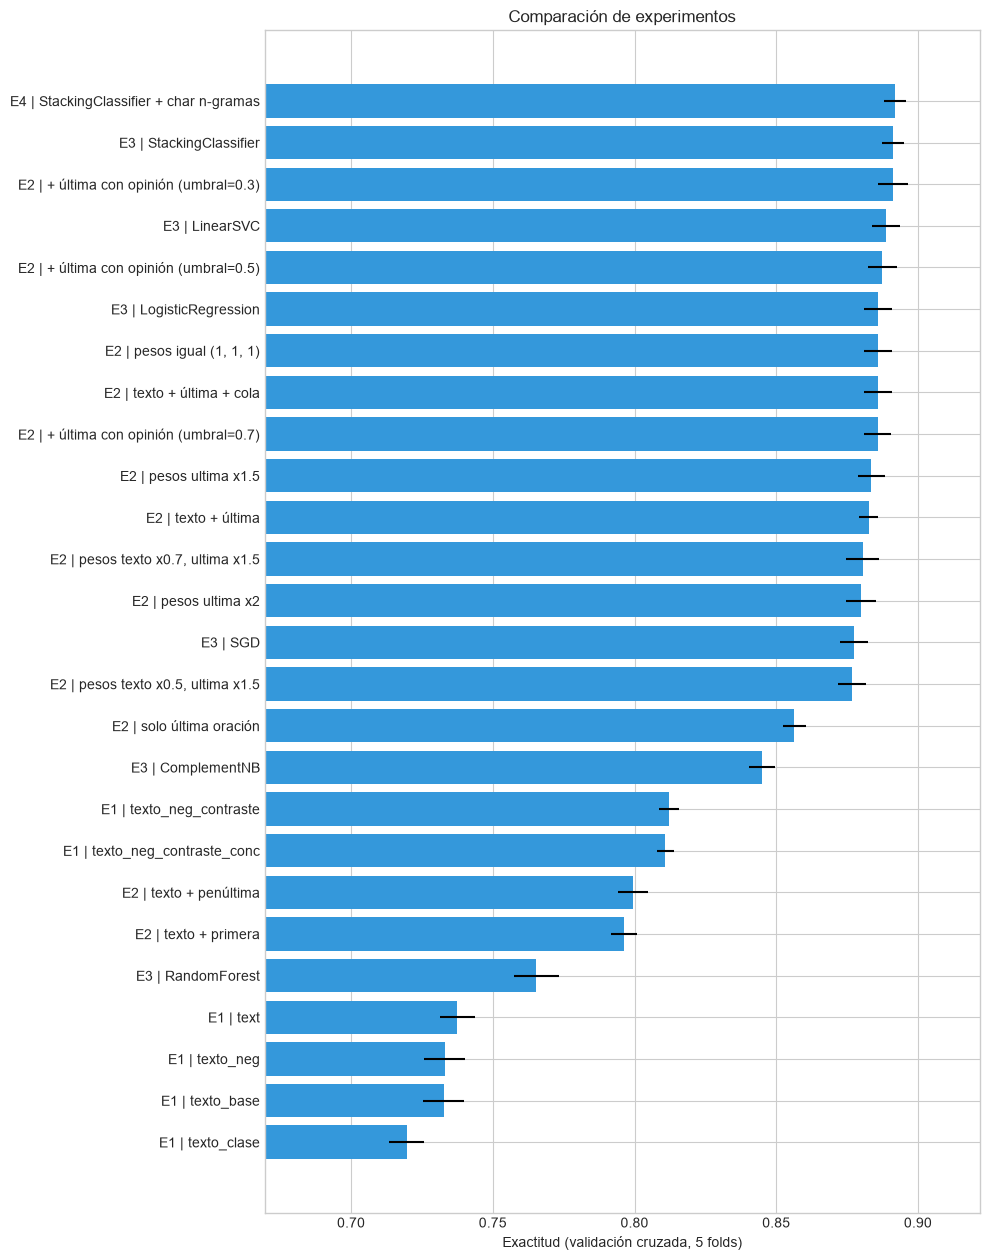

In [62]:
tabla_resultados = pd.DataFrame(resultados)
display(tabla_resultados.style.format({'acc_cv': '{:.4f}', 'std_cv': '{:.4f}', 'acc_train': '{:.4f}'})
        .background_gradient(subset=['acc_cv'], cmap='Greens'))

fig, ax = plt.subplots(figsize=(10, 0.45 * len(tabla_resultados) + 1))
orden = tabla_resultados.sort_values('acc_cv')
ax.barh(orden['experimento'], orden['acc_cv'], xerr=orden['std_cv'], color='#3498DB')
ax.set_xlim(orden['acc_cv'].min() - 0.05, min(1, orden['acc_cv'].max() + 0.03))
ax.set_xlabel('Exactitud (validación cruzada, 5 folds)')
ax.set_title('Comparación de experimentos')
plt.tight_layout()
plt.show()

### **8. Ajuste de hiperparámetros**

Sobre la mejor combinación (representación + clasificador) se hace una búsqueda en malla con la misma validación cruzada. Se ajustan la regularización del clasificador y el rango de n-gramas” pasa a “Se ajustan la regularización del clasificador, el rango de n-gramas y el peso relativo de cada columna (texto, última oración, cola).

Búsqueda terminada en 801 s
Mejor exactitud CV: 0.8923
Mejores parámetros: {'clf__final_estimator__C': 10, 'tfidf__cola_prep__ngram_range': (1, 2), 'tfidf__texto_neg_contraste__ngram_range': (1, 2), 'tfidf__transformer_weights': {'texto_neg_contraste': 1.0, 'ultima_prep': 1.0, 'cola_prep': 1.0}, 'tfidf__ultima_prep__ngram_range': (1, 2)}


,reg,pesos,mean_test_score,std_test_score,mean_train_score
15,10.0,texto 1.0 / ultima 1.0 / cola 1.0,0.8923,0.0035,0.9866
10,3.0,texto 1.0 / ultima 1.0 / cola 1.0,0.8922,0.0034,0.9867
5,1.0,texto 1.0 / ultima 1.0 / cola 1.0,0.8913,0.0036,0.9871
0,0.3,texto 1.0 / ultima 1.0 / cola 1.0,0.8909,0.0032,0.9875
19,10.0,texto 1.0 / ultima 1.5 / cola 0.7,0.8888,0.0028,0.9844
14,3.0,texto 1.0 / ultima 1.5 / cola 0.7,0.8887,0.0027,0.9845
9,1.0,texto 1.0 / ultima 1.5 / cola 0.7,0.8879,0.0025,0.9845
4,0.3,texto 1.0 / ultima 1.5 / cola 0.7,0.8877,0.0026,0.9848


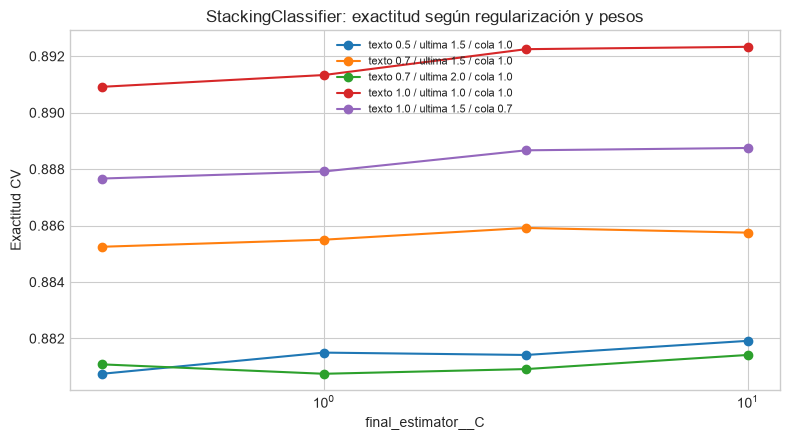

In [63]:
clf_base, grid_clf = CLASIFICADORES[MEJOR_CLF]
extra = [CHAR_ULTIMA] if USAR_CHAR else []
modelo_busqueda = modelo_columnas(COLUMNAS, clone(clf_base), extra=extra)

def mk_pesos(texto, ultima, cola):
    return {COLUMNAS[0]: texto, 'ultima_prep': ultima, 'cola_prep': cola}

def etiqueta_pesos(w):
    return f"texto {w[COLUMNAS[0]]} / ultima {w['ultima_prep']} / cola {w['cola_prep']}"

GRID_PESOS = [
    mk_pesos(1.0, 1.0, 1.0),
    mk_pesos(0.7, 1.5, 1.0),
    mk_pesos(0.5, 1.5, 1.0),
    mk_pesos(0.7, 2.0, 1.0),
    mk_pesos(1.0, 1.5, 0.7),
]

param_grid = [
    {**grid_clf,
     **{f'tfidf__{col}__ngram_range': [ng] for col in COLUMNAS},
     'tfidf__transformer_weights': GRID_PESOS}
    for ng in [(1, 2)]
]

inicio = time.time()
busqueda = GridSearchCV(modelo_busqueda, param_grid, cv=CV_BUSQUEDA, scoring='accuracy', n_jobs=-1, return_train_score=True)
busqueda.fit(train, train['label'])
print(f'Búsqueda terminada en {time.time() - inicio:.0f} s')
print(f'Mejor exactitud CV: {busqueda.best_score_:.4f}')
print('Mejores parámetros:', busqueda.best_params_)

param_reg = list(grid_clf)[0]
cv_res = pd.DataFrame(busqueda.cv_results_)
cv_res['pesos'] = cv_res['param_tfidf__transformer_weights'].map(etiqueta_pesos)
cv_res['reg'] = cv_res[f'param_{param_reg}'].astype(float)

display(cv_res.sort_values('rank_test_score')
        [['reg', 'pesos', 'mean_test_score', 'std_test_score', 'mean_train_score']].head(8).round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
for etiqueta, g in cv_res.groupby('pesos'):
    g = g.sort_values('reg')
    ax.plot(g['reg'], g['mean_test_score'], marker='o', label=etiqueta)
ax.set_xscale('log')
ax.set_xlabel(param_reg.replace('clf__', ''))
ax.set_ylabel('Exactitud CV')
ax.set_title(f'{MEJOR_CLF}: exactitud según regularización y pesos')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

resultados.append({'experimento': f'E5 | {MEJOR_CLF} ajustado (5 folds)', 'acc_cv': busqueda.best_score_,
                   'std_cv': cv_res.loc[busqueda.best_index_, 'std_test_score'],
                   'acc_train': cv_res.loc[busqueda.best_index_, 'mean_train_score'],
                   'segundos': round(time.time() - inicio, 1)})

**Resultados del ajuste:** la mejor configuración es C = 0.5 con uni y bigramas (0.8905), la misma con la que se partió.

- **La mejor configuración es C = 10 en el clasificador final del stacking, uni y bigramas en las tres columnas y sin ponderar las columnas (texto 1.0 / última 1.0 / cola 1.0), con exactitud 0.8923 ± 0.0035** (train 0.9866).
- **Ponderar las columnas empeora el resultado.** La mejor combinación ponderada (texto 1.0 / última 1.5 / cola 0.7) alcanza 0.8888, unos 0.35 puntos por debajo de no ponderar. Cuanto más peso se traslada a la última oración y se resta al texto completo, peor: (0.7 / 1.5 / 1.0) queda en ≈0.886, (0.5 / 1.5 / 1.0) en ≈0.882 y (0.7 / 2.0 / 1.0) en ≈0.881, es decir, más de 1 punto por debajo. Una explicación posible es que cada bloque TF-IDF ya está normalizado y el clasificador aprende los coeficientes de cada característica, de modo que el equilibrio por defecto ya funciona. Además, el texto completo conserva la información de lo que va después de los conectores (prefijo `tras_`) y no conviene restarle peso.
- **La regularización del clasificador final apenas importa.** Para cada combinación de pesos, subir C de 0.3 a 10 mueve la exactitud menos de 0.2 puntos (sin ponderar: de 0.8909 a 0.8923, +0.14 puntos), por debajo de la desviación entre folds (0.0035). La mejor C es el extremo superior de la malla, pero la curva se aplana entre C = 3 (0.8922) y C = 10 (0.8923), así que extender la malla no daría una mejora apreciable.
- **La superficie es plana respecto a C, pero no respecto a los pesos:** las combinaciones evaluadas van de ≈0.881 a 0.8923, y esa diferencia (≈1.1 puntos) se explica casi por completo por los pesos. El techo lo sigue poniendo la representación, no el ajuste fino.
- **El sobreajuste persiste:** la exactitud de entrenamiento (0.984 a 0.987 en todas las configuraciones) supera en unos 9 puntos a la de validación, y no baja al regularizar el clasificador final. Los estimadores base del stacking mantienen sus hiperparámetros fijos, y ahí es donde el modelo memoriza.

### **9. Análisis de errores**

Se obtienen predicciones *out-of-fold* (cada reseña es predicha por un modelo que no la vio en entrenamiento) para analizar en qué se equivoca el mejor modelo.

              precision    recall  f1-score   support

    negativo     0.8529    0.8538    0.8533      4212
     neutral     0.9833    0.9908    0.9870      3576
    positivo     0.8536    0.8473    0.8505      4212

    accuracy                         0.8923     12000
   macro avg     0.8966    0.8973    0.8970     12000
weighted avg     0.8920    0.8923    0.8922     12000



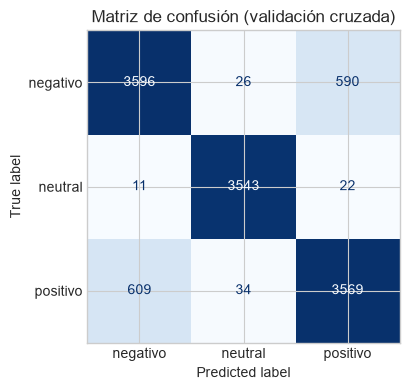

In [64]:
CV_PRED = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

modelo_final = busqueda.best_estimator_
pred_cv = cross_val_predict(clone(modelo_final), train, train['label'], cv=CV_PRED, n_jobs=-1)

print(classification_report(train['label'], pred_cv, digits=4))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(train['label'], pred_cv, labels=CLASES, cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Matriz de confusión (validación cruzada)')
plt.tight_layout()
plt.show()

In [66]:
clf_final = modelo_final.named_steps['clf']
base_lineal = clf_final.named_estimators_['lr'] if hasattr(clf_final, 'named_estimators_') else clf_final
if hasattr(base_lineal, 'coef_'):
    nombres = modelo_final.named_steps['tfidf'].get_feature_names_out()
    coefs = pd.DataFrame(base_lineal.coef_.T, index=nombres, columns=clf_final.classes_)
    top = {clase: coefs[clase].nlargest(12).index.tolist() for clase in CLASES}
    display(pd.DataFrame(top))

,negativo,neutral,positivo
0,ultima_prep__mal,texto_neg_contraste__vien,texto_neg_contraste__encim medi
1,cola_prep__tras_mal,texto_neg_contraste__tra,texto_neg_contraste__verd
2,ultima_prep__tras_mal,texto_neg_contraste__paquet,texto_neg_contraste__encant
3,ultima_char__ mal,texto_neg_contraste__color,texto_neg_contraste__encim
4,ultima_prep__poco fiabl,texto_neg_contraste__unidad,cola_prep__tras_bien
5,texto_neg_contraste__muy,texto_neg_contraste__kil,ultima_prep__comod
6,ultima_char__mal,texto_neg_contraste__puert,texto_neg_contraste__cinc estrell
7,texto_neg_contraste__qued muy,texto_neg_contraste__volti,ultima_prep__feliz
8,texto_neg_contraste__decepcion,texto_neg_contraste__segun,texto_neg_contraste__calid
9,texto_neg_contraste__dias caj,texto_neg_contraste__ven,texto_neg_contraste__just busc


In [67]:
errores = train.assign(pred=pred_cv).loc[lambda d: d['pred'] != d['label'], ['label', 'pred', 'text']]
print(f'Errores: {len(errores):,} de {len(train):,} ({len(errores) / len(train):.1%})')
with pd.option_context('display.max_colwidth', None):
    display(errores.sample(6, random_state=SEMILLA))

Errores: 1,292 de 12,000 (10.8%)


,label,pred,text
3275,negativo,positivo,"Lo pedí a mediados de mes y llegó en tres días a mi casa en Guadalajara. Hace unas dos semanas que lo estoy probando a fondo, lo uso casi a diario en las tardes después del trabajo. La aplicación se dañó antes de lo que esperaba, apenas llevaba poco con el aparato. Seguí los pasos del manual para reinstalarla y aún así sigue fallando."
4375,positivo,negativo,"Me llegó el pedido un martes a la oficina, tardó cuatro días desde que hice la compra. El rendimiento funciona de maravilla, lo uso a diario desde que lo instalé. Lo revisé con calma un rato en la mesa antes de armarlo todo. El ensamblaje no vale lo que cuesta."
5437,positivo,negativo,"Me llegó el paquete en cuatro días a la casa, pedí el color negro nomás porque era el que quedaba. Doy mi punto de vista. La construcción me dio más de un dolor de cabeza, la venía armando en las noches después del trabajo, y terminé feliz con el motor. La verdad es que lo uso en el taller del patio un rato cada semana. Sigo con dudas, la verdad."
4040,neutral,positivo,"Lo pedí en oferta hace unas semanas y llegó en tres días a mi casa. Venían tres unidades en el paquete, así que alcancé para compartir con mi hermana. Lo uso en la oficina desde entonces. Por lo que costó, salió bien de precio."
2651,negativo,positivo,"Hace unos dias, se lo compre a un familiar. Le pondria una estrella al diseno. Ademas, la construccion me sorprendio para bien. Sigo con dudas, la verdad."
9224,positivo,negativo,"Ya llevo unas semanas con esto y lo estoy probando a fondo en el día a día. Lo compré a principios de mes y me llegó en cuatro días. Me alegra haber elegido la resistencia al agua, la uso hasta para lavar los trastos. Eso sí, la terminación no vale lo que cuesta. Ni tan bueno ni tan malo, la verdad ando medio indeciso todavía."


**Análisis de errores:**

- **La clase neutral está prácticamente resuelta** (recall 0.995). Las reseñas neutrales no tienen palabras de opinión, y eso una bolsa de palabras lo detecta fácilmente.
- **Casi todos los errores son confusiones negativo ↔ positivo** en reseñas mixtas (un elogio y una queja). Allí el F1 baja a ~0.85.
- Las palabras con más peso para positivo y negativo vienen casi todas del segmento ultima_prep lo que confirma que el modelo aprendió a mirar el final de la reseña.
- Hay dos tipos de error:
  1. **Errores del modelo:** la última opinión no está en la última oración porque la reseña termina con una frase de cierre sin sentimiento ("Hay de todo, como se ve", "Sopésalo tú mismo", "Todavía no me decido"), o la opinión llega con un conector que no está en la lista ("Por cierto", "De paso", "Ahora,").
  2. **Casos que contradicen la regla de recencia:** reseñas cuya última opinión es negativa pero están etiquetadas como positivas (y viceversa), como las de índices 8855 y 3891. Pueden ser ruido de etiqueta o depender de algo que el texto no hace explícito. En cualquier caso, ponen un techo a lo que puede lograr una representación de bolsa de palabras.

### **10. Modelo final reproducible**

Para que el modelo entregado sea completamente replicable, se empaqueta **todo** el flujo en un único Pipeline que recibe el texto crudo: reparación de codificación, segmentación, preprocesamiento, vectorización y clasificación. Se entrena con todo train, se verifica que da exactamente las mismas predicciones que el modelo de la búsqueda y se guarda con joblib.



In [68]:
def construir_columnas(df, col_texto, kw_prep):
    """Del texto crudo genera las columnas que espera el modelo (misma lógica de las secciones 4 y 5)."""
    texto = df['text'].fillna('')
    ultima = texto.apply(ultima_oracion)
    return pd.DataFrame({
        col_texto: texto.apply(preprocesar, **kw_prep),
        'ultima_prep': ultima.apply(preprocesar, **kw_prep),
        'cola_prep': texto.apply(cola_contraste).apply(preprocesar, **kw_prep),
        'ultima': ultima,
    }, index=df.index)

pipeline_final = Pipeline([
    ('columnas', FunctionTransformer(construir_columnas, kw_args={'col_texto': MEJOR_VARIANTE, 'kw_prep': KW_PREP})),
    ('modelo', clone(modelo_final)),
])
pipeline_final.fit(train_raw[['text']], train_raw['label'])

pred_eval = pipeline_final.predict(eval_raw[['text']])
assert (pred_eval == modelo_final.predict(eval_df)).all(), 'El pipeline final no reproduce al modelo de la búsqueda'
print('✓ El pipeline sobre texto crudo reproduce exactamente las predicciones del modelo seleccionado')

Path('modelos').mkdir(exist_ok=True)
RUTA_MODELO = Path('modelos/modelo_final.joblib')
joblib.dump(pipeline_final, RUTA_MODELO)
cargado = joblib.load(RUTA_MODELO)
assert (cargado.predict(eval_raw[['text']]) == pred_eval).all()
print(f'✓ Modelo guardado y recargado correctamente: {RUTA_MODELO} ({RUTA_MODELO.stat().st_size / 1e6:.1f} MB)')

✓ El pipeline sobre texto crudo reproduce exactamente las predicciones del modelo seleccionado
✓ Modelo guardado y recargado correctamente: modelos\modelo_final.joblib (9.6 MB)


In [69]:
sample = pd.read_csv('data/sample_submission.csv')
Path('envios').mkdir(exist_ok=True)

def guardar_envio(nombre, predicciones):
    envio = pd.DataFrame({'id': eval_raw['id'], 'answer': predicciones})
    assert list(envio.columns) == list(sample.columns) and envio['id'].equals(sample['id'])
    assert envio['answer'].isin(CLASES).all()
    ruta = Path('envios') / f'{nombre}.csv'
    envio.to_csv(ruta, index=False)
    return ruta

ruta = guardar_envio('envio_05_modelo_final', pred_eval)
print(f'✓ Envío final: {ruta}')
display(pd.Series(pred_eval).value_counts(normalize=True).reindex(CLASES).round(3).to_frame('proporción predicha'))

✓ Envío final: envios\envio_05_modelo_final.csv


,proporción predicha
negativo,0.361
neutral,0.281
positivo,0.359


In [70]:
HITOS = {
    'envio_01_linea_base_clase':  ('Limpieza de clase + TF-IDF + LogReg', modelo_columnas(['texto_clase'])),
    'envio_02_preprocesar':       (f'{MEJOR_VARIANTE} + TF-IDF + LogReg', modelo_columnas([MEJOR_VARIANTE])),
    'envio_03_ultima_oracion':    ('+ TF-IDF de la última oración', modelo_columnas([MEJOR_VARIANTE, 'ultima_prep'])),
    'envio_04_cola_contraste':    ('+ TF-IDF de la cola contrastiva (LogReg)', modelo_columnas(COLUMNAS)),
}
acc_por_hito = {'envio_01_linea_base_clase': e1['texto_clase'], 'envio_02_preprocesar': e1[MEJOR_VARIANTE],
                'envio_03_ultima_oracion': e2['texto + última'], 'envio_04_cola_contraste': e2['texto + última + cola']}

registro = []
for nombre, (descripcion, modelo) in HITOS.items():
    guardar_envio(nombre, modelo.fit(train, train['label']).predict(eval_df))
    registro.append({'archivo': f'{nombre}.csv', 'descripcion': descripcion, 'acc_cv': acc_por_hito[nombre]})
registro.append({'archivo': 'envio_05_modelo_final.csv', 'descripcion': f"{MEJOR_CLF} ajustado ({param_reg.replace('clf__', '')} = {busqueda.best_params_[param_reg]})",
                 'acc_cv': busqueda.best_score_})

registro = pd.DataFrame(registro)
registro['kaggle_publico'] = np.nan   # completar con el puntaje público de cada envío
display(registro.round(4))

,archivo,descripcion,acc_cv,kaggle_publico
0,envio_01_linea_base_clase.csv,Limpieza de clase + TF-IDF + LogReg,0.7196,NaN
1,envio_02_preprocesar.csv,texto_neg_contraste + TF-IDF + LogReg,0.8121,NaN
2,envio_03_ultima_oracion.csv,+ TF-IDF de la última oración,0.8826,NaN
3,envio_04_cola_contraste.csv,+ TF-IDF de la cola contrastiva (LogReg),0.8859,NaN
4,envio_05_modelo_final.csv,StackingClassifier ajustado (final_estimator__...,0.8923,NaN


### **12. Conclusiones**

1. **El modelo final es un LinearSVC (C = 0.5) sobre tres TF-IDF de uni y bigramas**: texto completo con negación y marcas de contraste, última oración y cola desde el último conector contrastivo. Su exactitud en validación cruzada es **0.8905 ± 0.003**, frente a **0.718** de la línea base de clase.
2. **Lo que más aportó fue representar la posición, no cambiar de clasificador ni ajustar hiperparámetros.** El sentimiento global depende del orden de las cláusulas, y una bolsa de palabras sobre el texto completo lo ignora. Segmentar el texto (última oración, cola contrastiva) y marcar lo que va después de los conectores permitió inyectar parte de ese orden sin salir de las técnicas clásicas.
3. **Las decisiones de preprocesamiento deben adaptarse a la tarea.** Eliminar las *stopwords* genéricas borra *no*, *pero* y *muy*, que son claves para el sentimiento, y un *stemmer* en inglés no sirve para el español.
4. **Limitaciones:** la segmentación usa reglas fijas (lista de conectores, última oración) que fallan cuando la reseña termina con una frase de cierre neutral o usa un conector no contemplado. Una parte de los errores contradice incluso la regla de recencia.
5. **Siguiente paso (Parte 2):** un modelo secuencial (RNN, LSTM o *transformer*) puede aprender directamente cuál es la última cláusula con opinión, en lugar de depender de reglas, que es justo la limitación que deja este modelo.

**Reproducibilidad:** el archivo modelos/modelo_final.joblib contiene el pipeline completo (texto crudo → predicción) y corresponde al envío envios/envio_05_modelo_final.csv. Se entrena con semilla fija (SEMILLA = 42) y el notebook verifica que el modelo recargado reproduce exactamente las mismas predicciones.